In [1]:
import pandas as pd



df = df = pd.read_excel(
    "data/FinalFactors-Influencing-Customer-Satisfaction-in-Digital-Banking-Perspective-of-Generation-Z-Users.xlsx"
)
print(df.shape)
print(df.head())
print(df.columns)

import re

def extract_code(column):
    match = re.match(r'^\s*(TR|SEC|CON|EFF|CST)\s*(\d+)', str(column))
    
    if match:
        return f"{match.group(1)}{match.group(2)}"
    
    return column.strip()

df = df.rename(columns=extract_code)

# print("Hello", df.columns.tolist())

print(df.columns.tolist())
print(df.shape)

print(df.isnull().sum())

print(df.head())

likert_columns = [
    "TR1", "TR2", "TR3", "TR4", "TR5",
    "SEC1", "SEC2", "SEC3", "SEC4", "SEC5",
    "CON1", "CON2", "CON3", "CON4", "CON5",
    "EFF1", "EFF2", "EFF3", "EFF4",
    "CST1", "CST2", "CST3", "CST4", "CST5"
]

for col in likert_columns:
    print(col, df[col].unique())

(100, 31)
  1. Gender 2. Age                3.Education 4.Employment status  \
0    Female  23–27  Master’s degree or higher            Employed   
1    Female  23–27  Master’s degree or higher        own business   
2      Male  18–22          Bachelor’s degree             Student   
3      Male  18–22          Bachelor’s degree             Student   
4      Male  23–27                    Diploma        own business   

  5.How frequently do you use digital banking applications  \
0                                              Daily         
1                               Several times a week         
2                               Several times a week         
3                               Several times a week         
4                              Once or twice a month         

  6. How long have you been using digital banking apps?  \
0                                 More than 6 months      
1                                 More than 6 months      
2                        

In [22]:
df["Trust"] = df[
    ["TR1", "TR2", "TR3", "TR4", "TR5"]
].mean(axis=1)


In [23]:
df["Security"] = df[
    ["SEC1", "SEC2", "SEC3", "SEC4", "SEC5"]
].mean(axis=1)

In [24]:
df["Convenience"] = df[
    ["CON1", "CON2", "CON3", "CON4", "CON5"]
].mean(axis=1)

In [25]:
df["Efficiency"] = df[
    ["EFF1", "EFF2", "EFF3", "EFF4"]
].mean(axis=1)

In [26]:
df["Satisfaction"] = df[
    ["CST1", "CST2", "CST3", "CST4", "CST5"]
].mean(axis=1)

                mean       std
Trust         3.7900  0.516691
Security      3.7920  0.471336
Convenience   4.1080  0.373268
Efficiency    4.0825  0.311916
Satisfaction  4.1000  0.335749


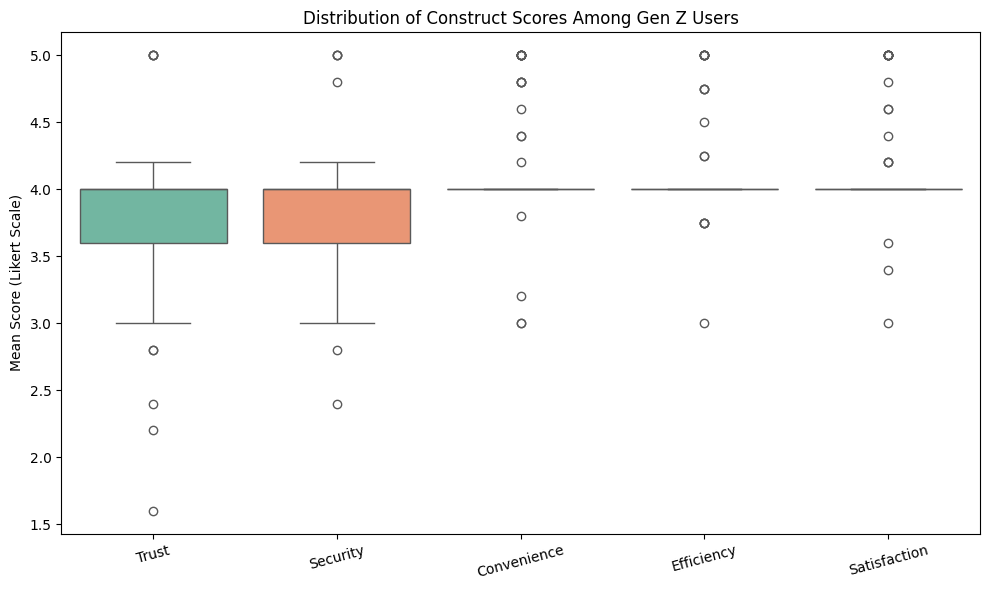

In [27]:
constructs = [
    "Trust",
    "Security",
    "Convenience",
    "Efficiency",
    "Satisfaction"
]

summary = df[constructs].agg(["mean", "std"]).T

print(summary)
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.boxplot(data=df[["Trust", "Security", "Convenience", "Efficiency", "Satisfaction"]], palette="Set2")
plt.title("Distribution of Construct Scores Among Gen Z Users")
plt.ylabel("Mean Score (Likert Scale)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

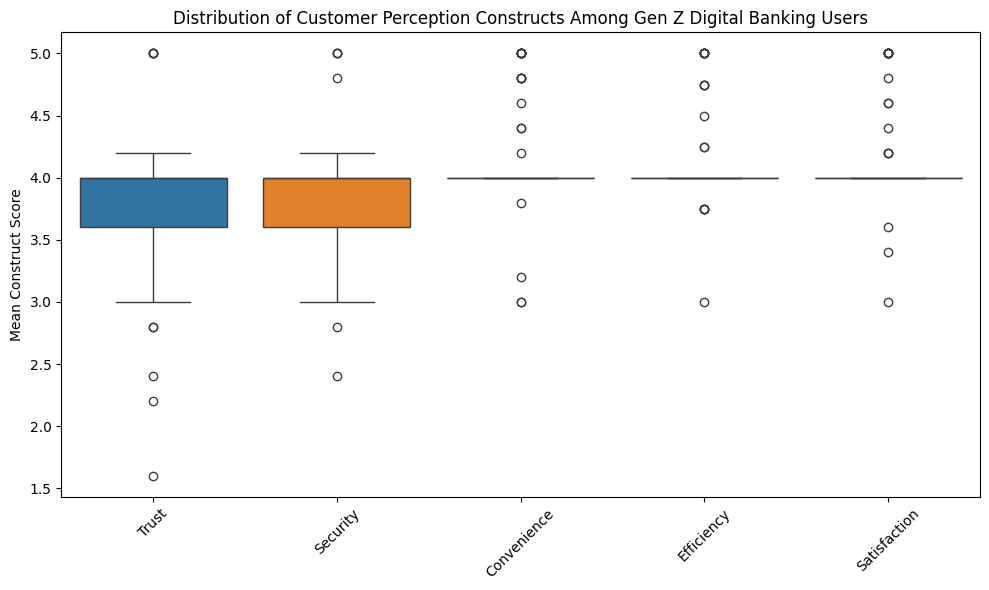

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[constructs])
plt.title(
    "Distribution of Customer Perception Constructs Among Gen Z Digital Banking"
    " Users"
)
plt.ylabel("Mean Construct Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [19]:
def cronbach_alpha(df, item_cols):
  item_scores = df[item_cols]
  k = len(item_cols)
  variance_sum = item_scores.var(ddof=1).sum()
  total_score = item_scores.sum(axis=1)
  total_variance = total_score.var(ddof=1)
  return (k / (k - 1)) * (1 - (variance_sum / total_variance))


# Test reliability for Trust construct
trust_alpha = cronbach_alpha(
    df, ["TR1", "TR2", "TR3", "TR4", "TR5"]
)
print(f"Cronbach's Alpha for Trust: {trust_alpha:.3f}")

Cronbach's Alpha for Trust: 0.935


In [20]:
print(df.columns.tolist())


['1. Gender', '2. Age', '3.Education', '4.Employment status', '5.How frequently do you use digital banking applications', '6. How long have you been using digital banking apps?', '7.Which digital banking app(s) do you currently use? (Select all that apply)', 'TR1', 'TR2', 'TR3', 'TR4', 'TR5', 'SEC1', 'SEC2', 'SEC3', 'SEC4', 'SEC5', 'CON1', 'CON2', 'CON3', 'CON4', 'CON5', 'EFF1', 'EFF2', 'EFF3', 'EFF4', 'CST1', 'CST2', 'CST3', 'CST4', 'CST5']


In [18]:
import re

def extract_code(column):
    match = re.match(r'^\s*(TR|SEC|CON|EFF|CST)\s*(\d+)', str(column))
    if match:
        return f"{match.group(1)}{match.group(2)}"
    return column.strip()

df = df.rename(columns=extract_code)


In [29]:
# Check distribution of Gender
print("--- GENDER BREAKDOWN ---")
print(df["1. Gender"].value_counts(normalize=True) * 100)

# Check distribution of Age groups
print("\n--- AGE BREAKDOWN ---")
print(df["2. Age"].value_counts(normalize=True) * 100)

# Check distribution of Education level
print("\n--- EDUCATION BREAKDOWN ---")
print(df["3.Education"].value_counts(normalize=True) * 100)

# Check distribution of Employment Status
print("\n--- EMPLOYMENT STATUS BREAKDOWN ---")
print(df["4.Employment status"].value_counts(normalize=True) * 100)


--- GENDER BREAKDOWN ---
1. Gender
Female    68.0
Male      32.0
Name: proportion, dtype: float64

--- AGE BREAKDOWN ---
2. Age
23–27    81.0
18–22    19.0
Name: proportion, dtype: float64

--- EDUCATION BREAKDOWN ---
3.Education
Bachelor’s degree            62.0
Master’s degree or higher    37.0
Diploma                       1.0
Name: proportion, dtype: float64

--- EMPLOYMENT STATUS BREAKDOWN ---
4.Employment status
Employed         63.0
Student          22.0
own business     14.0
Self-employed     1.0
Name: proportion, dtype: float64


/var/folders/01/cd76mmls07d0pdv6x7l02vlh0000gn/T/ipykernel_8788/719645229.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="1. Gender", ax=axes[0, 0], palette="Set2")
/var/folders/01/cd76mmls07d0pdv6x7l02vlh0000gn/T/ipykernel_8788/719645229.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="2. Age", ax=axes[0, 1], palette="Set2")
/var/folders/01/cd76mmls07d0pdv6x7l02vlh0000gn/T/ipykernel_8788/719645229.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="3.Education", ax=axes[1, 0], palette="Set

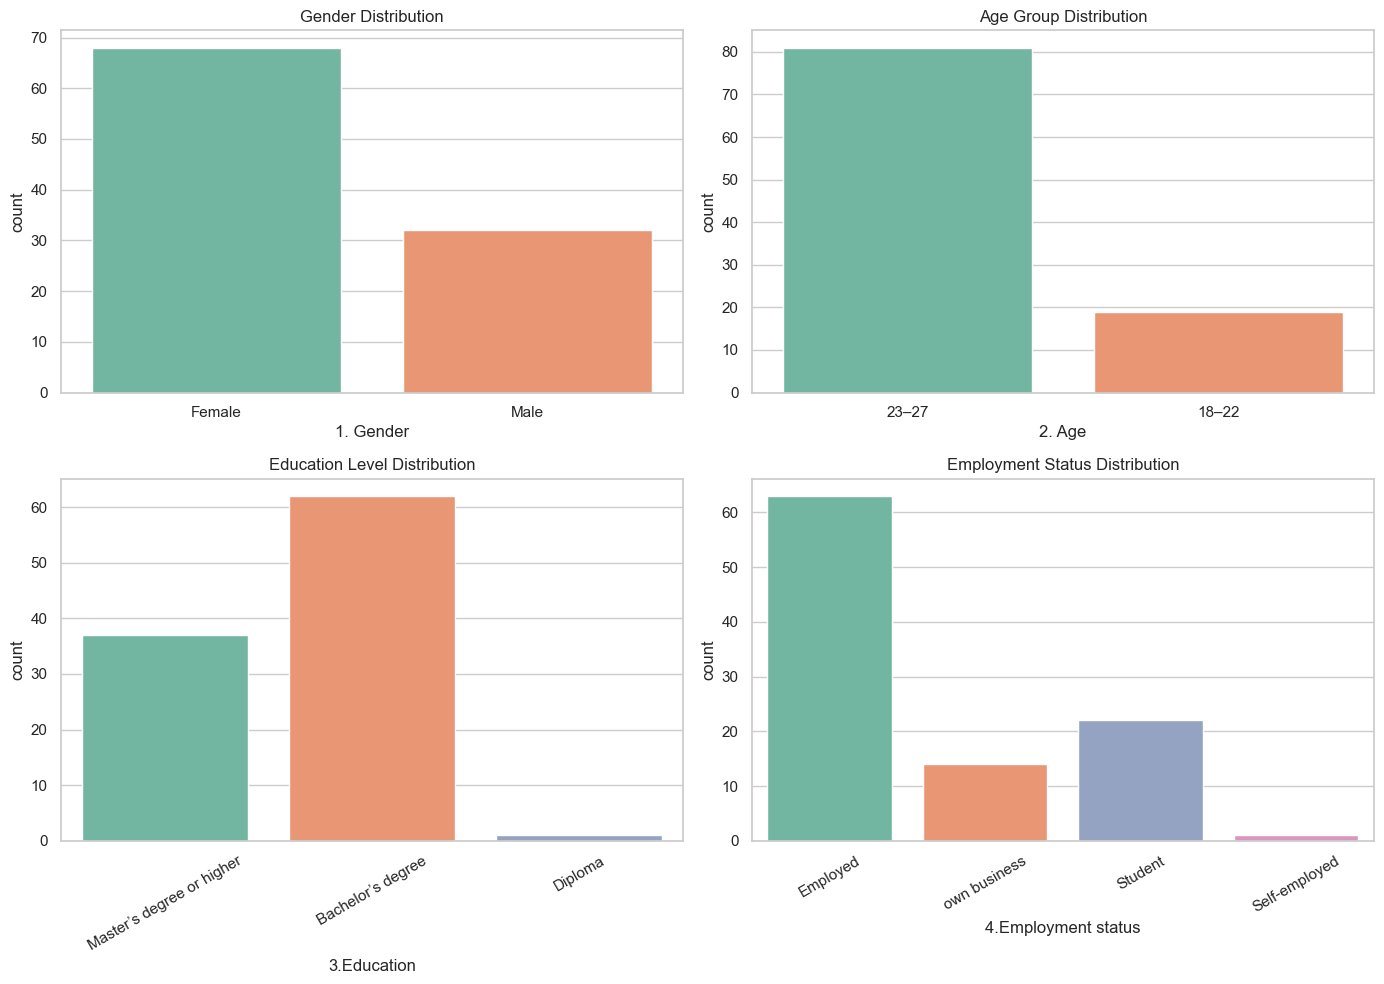

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gender Plot
sns.countplot(data=df, x="1. Gender", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Gender Distribution")

# 2. Age Plot
sns.countplot(data=df, x="2. Age", ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Age Group Distribution")

# 3. Education Plot
sns.countplot(data=df, x="3.Education", ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Education Level Distribution")
axes[1, 0].tick_params(axis='x', rotation=30)

# 4. Employment Status Plot
sns.countplot(data=df, x="4.Employment status", ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Employment Status Distribution")
axes[1, 1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
